In [2]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_data.csv to cleaned_data.csv


Dataset Shape: (388805, 19)
   Invoice Product_ID                          Description  Quantity  \
0   536365     85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1   536365      71053                  WHITE METAL LANTERN         6   
2   536365     84406B       CREAM CUPID HEARTS COAT HANGER         8   
3   536365     84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4   536365     84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          Invoice_Date  Price  Customer_ID         Country  Year  Month  Day  \
0  2010-12-01 08:26:00   2.55        17850  United Kingdom  2010     12    1   
1  2010-12-01 08:26:00   3.39        17850  United Kingdom  2010     12    1   
2  2010-12-01 08:26:00   2.75        17850  United Kingdom  2010     12    1   
3  2010-12-01 08:26:00   3.39        17850  United Kingdom  2010     12    1   
4  2010-12-01 08:26:00   3.39        17850  United Kingdom  2010     12    1   

   DayOfWeek  Total_Amount  Recency  Frequency  Monetary  

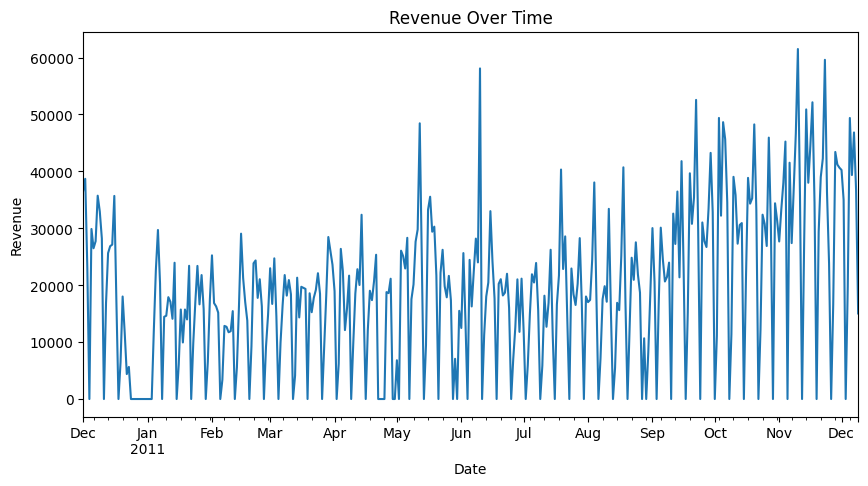

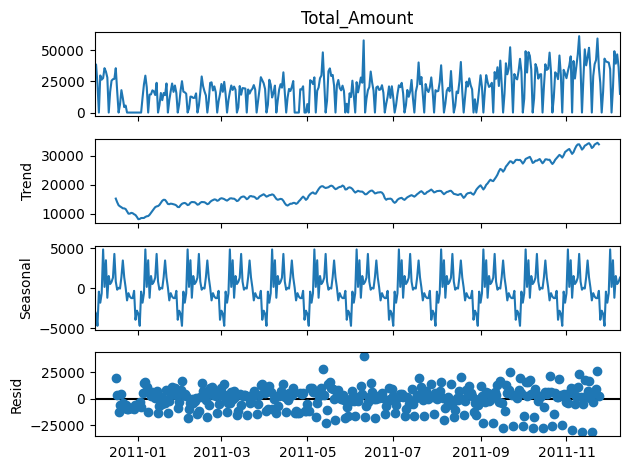


✅ MAE: 12406.458075212744


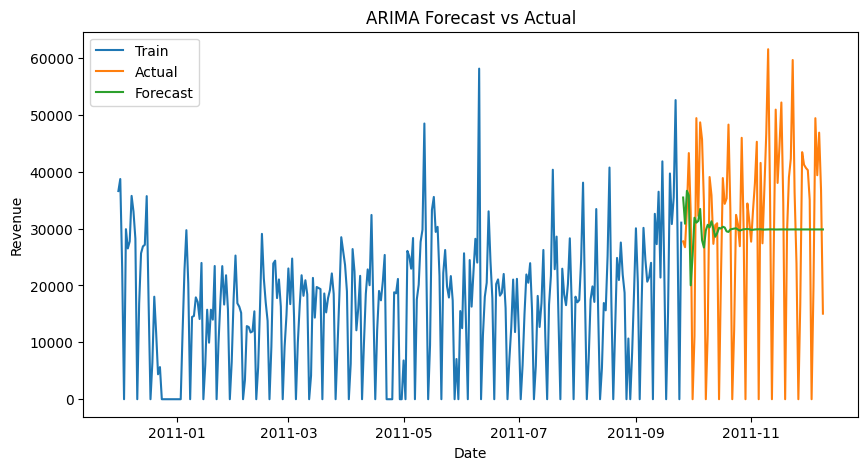

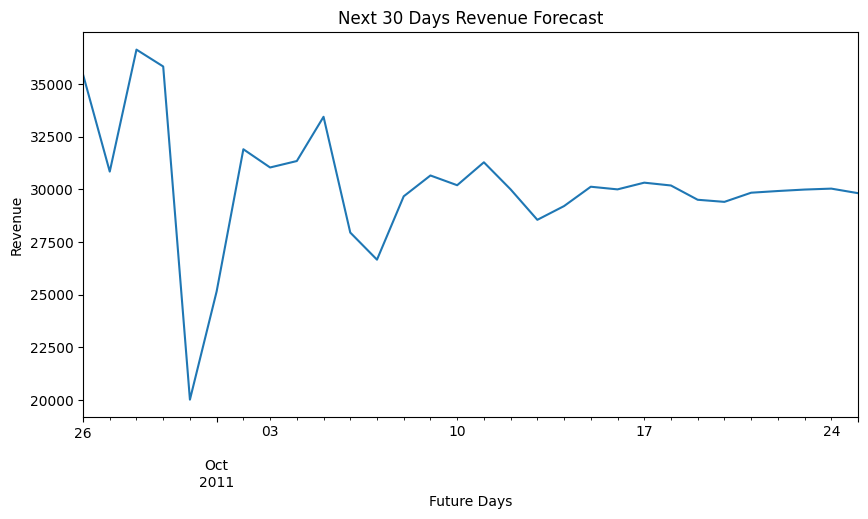


📈 Future 30 Days Forecast:
2011-09-26    35443.634823
2011-09-27    30835.027893
2011-09-28    36621.937069
2011-09-29    35821.778021
2011-09-30    20016.998913
2011-10-01    25152.160438
2011-10-02    31895.029134
2011-10-03    31030.536668
2011-10-04    31336.315046
2011-10-05    33435.570217
2011-10-06    27942.587134
2011-10-07    26656.735156
2011-10-08    29662.520687
2011-10-09    30650.911825
2011-10-10    30188.520226
2011-10-11    31276.361234
2011-10-12    29991.524567
2011-10-13    28547.391950
2011-10-14    29199.532043
2011-10-15    30117.195415
2011-10-16    29991.479997
2011-10-17    30309.781526
2011-10-18    30176.098439
2011-10-19    29498.808139
2011-10-20    29398.973449
2011-10-21    29833.389667
2011-10-22    29913.644206
2011-10-23    29983.040743
2011-10-24    30027.459415
2011-10-25    29811.568138
Freq: D, Name: predicted_mean, dtype: float64


In [3]:
# ==============================
# STEP 1: IMPORT LIBRARIES
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import joblib

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error

# ==============================
# STEP 2: LOAD DATA
# ==============================

df = pd.read_csv("cleaned_data.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ==============================
# STEP 3: CONVERT TO TIME SERIES
# ==============================

df['Invoice_Date'] = pd.to_datetime(df['Invoice_Date'], errors='coerce')

# Remove invalid dates
df = df.dropna(subset=['Invoice_Date'])

# Aggregate daily revenue
ts = df.groupby('Invoice_Date')['Total_Amount'].sum()

# Sort by date
ts = ts.sort_index()

# ==============================
# STEP 4: RESAMPLE (DAILY)
# ==============================

ts = ts.resample('D').sum()
ts = ts.fillna(0)

print("\nTime Series Sample:")
print(ts.head())

# ==============================
# STEP 5: VISUALIZE
# ==============================

plt.figure(figsize=(10,5))
ts.plot()
plt.title("Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

# ==============================
# STEP 6: DECOMPOSITION
# ==============================

decompose = seasonal_decompose(ts, model='additive', period=30)
decompose.plot()
plt.show()

# ==============================
# STEP 7: TRAIN-TEST SPLIT
# ==============================

train_size = int(0.8 * len(ts))
train = ts[:train_size]
test = ts[train_size:]

# ==============================
# STEP 8: TRAIN ARIMA MODEL
# ==============================

model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

# ==============================
# STEP 9: FORECAST ON TEST
# ==============================

forecast = model_fit.forecast(steps=len(test))

# ==============================
# STEP 10: EVALUATE MODEL
# ==============================

mae = mean_absolute_error(test, forecast)
print("\n✅ MAE:", mae)

# ==============================
# STEP 11: PLOT ACTUAL VS FORECAST
# ==============================

plt.figure(figsize=(10,5))

plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

# ==============================
# STEP 12: FUTURE FORECAST (30 DAYS)
# ==============================

future_forecast = model_fit.forecast(steps=30)

plt.figure(figsize=(10,5))
future_forecast.plot(title="Next 30 Days Revenue Forecast")
plt.xlabel("Future Days")
plt.ylabel("Revenue")
plt.show()

# ==============================
# STEP 13: SAVE MODEL
# ==============================

joblib.dump(model_fit, "forecast_model.pkl")

# ==============================
# STEP 14: PRINT FUTURE VALUES
# ==============================

print("\n📈 Future 30 Days Forecast:")
print(future_forecast)